<a href="https://colab.research.google.com/github/hodyek/lung-colon-cancer-histopathology/blob/main/Notebooks/01_data_understanding_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01: Data Understanding and Exploratory Data Analysis

## Overview
This notebook explores the LC25000 dataset before any preprocessing or modelling. The goal is to understand the data structure, verify class balance, inspect image quality, and document stain colour variation across the five tissue classes. All findings here directly inform the preprocessing decisions made in Notebook 02.

## Objectives
1. Mount Google Drive and verify the dataset folder structure.
2. Count images per class and confirm the dataset is balanced.
3. Visualise sample images from each class at full resolution.
4. Analyse pixel intensity distributions per class.
5. Analyse stain colour variation using the LAB colour space.
6. Check for corrupt or unreadable image files.
7. Document all observations to guide preprocessing in Notebook 02.

In [9]:
# Install staintools for stain analysis in later cells
!pip install staintools --quiet

import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2

from google.colab import drive

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("All libraries imported successfully.")# Install staintools for stain analysis in later cells
!pip install staintools --quiet

import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2

from google.colab import drive

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("All libraries imported successfully.")

All libraries imported successfully.
All libraries imported successfully.


In [10]:
# Mount Google Drive
drive.mount('/content/drive', force_remount=False)

# Project base path on Drive
BASE_DIR = Path('/content/drive/MyDrive/lung-colon-cancer-histopathology')
FIGURES_DIR = BASE_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Base directory : {BASE_DIR}")
print(f"Figures will be saved to : {FIGURES_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base directory : /content/drive/MyDrive/lung-colon-cancer-histopathology
Figures will be saved to : /content/drive/MyDrive/lung-colon-cancer-histopathology/figures


In [5]:
# Download LC25000 dataset directly from the official GitHub release
import zipfile

DATA_DIR = BASE_DIR / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = DATA_DIR / 'LC25000.zip'

# Only download if the zip does not already exist
if not ZIP_PATH.exists():
    print("Downloading LC25000 dataset (~1.85 GB). This takes a few minutes...")
    !wget -q --show-progress -O "{ZIP_PATH}" \
        "https://github.com/tampapath/lung_colon_image_set/archive/refs/heads/master.zip"
    print("Download complete.")
else:
    print("Zip file already exists. Skipping download.")

# Extract only if the image folders are not already there
EXTRACT_DIR = DATA_DIR / 'lung_colon_image_set'

if not EXTRACT_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print("Extraction complete.")
else:
    print("Dataset already extracted. Skipping.")

Zip file already exists. Skipping download.
Extracting dataset...
Extraction complete.


In [12]:
import os

data_dir = '/content/drive/MyDrive/lung-colon-cancer-histopathology/data'

for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 3:
        print(f'{indent}  ({len(files)} files)')
        dirs.clear()

data/
  lung_colon_image_set-master/
  lung_colon_image_set/
    lung_image_sets/
      lung_scc/
        (5000 files)
      lung_aca/
        (5000 files)
      lung_n/
        (5000 files)
    colon_image_sets/
      colon_aca/
        (5000 files)
      colon_n/
        (5000 files)


In [14]:
# Count the number of images in each class folder
counts = {}

for class_key, folder_path in CLASS_FOLDERS.items():
    images = list(folder_path.glob('*.jpeg')) + list(folder_path.glob('*.jpg'))
    counts[class_key] = len(images)

# Build a summary dataframe
count_df = pd.DataFrame({
    'Class Key'  : list(counts.keys()),
    'Full Name'  : [CLASS_LABELS[k] for k in counts.keys()],
    'Image Count': list(counts.values()),
})

print(count_df.to_string(index=False))
print(f"\nTotal images: {sum(counts.values())}")
print(f"Number of classes: {len(counts)}")

Class Key                    Full Name  Image Count
colon_aca         Colon Adenocarcinoma         5000
  colon_n          Benign Colon Tissue         5000
 lung_aca          Lung Adenocarcinoma         5000
   lung_n           Benign Lung Tissue         5000
 lung_scc Lung Squamous Cell Carcinoma         5000

Total images: 25000
Number of classes: 5


In [13]:
# Locate the image folders
# Dataset is at: data/lung_colon_image_set/

DATASET_ROOT = DATA_DIR / 'lung_colon_image_set'

CLASS_FOLDERS = {
    'colon_aca': DATASET_ROOT / 'colon_image_sets' / 'colon_aca',
    'colon_n'  : DATASET_ROOT / 'colon_image_sets' / 'colon_n',
    'lung_aca' : DATASET_ROOT / 'lung_image_sets'  / 'lung_aca',
    'lung_n'   : DATASET_ROOT / 'lung_image_sets'  / 'lung_n',
    'lung_scc' : DATASET_ROOT / 'lung_image_sets'  / 'lung_scc',
}

CLASS_LABELS = {
    'colon_aca': 'Colon Adenocarcinoma',
    'colon_n'  : 'Benign Colon Tissue',
    'lung_aca' : 'Lung Adenocarcinoma',
    'lung_n'   : 'Benign Lung Tissue',
    'lung_scc' : 'Lung Squamous Cell Carcinoma',
}

CLASS_NAMES  = list(CLASS_FOLDERS.keys())
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

# Verify all folders exist
print('Verifying class folders:')
for key, path in CLASS_FOLDERS.items():
    status = 'OK' if path.exists() else 'MISSING'
    print(f'  [{status}] {key} -> {path}')

Verifying class folders:
  [OK] colon_aca -> /content/drive/MyDrive/lung-colon-cancer-histopathology/data/lung_colon_image_set/colon_image_sets/colon_aca
  [OK] colon_n -> /content/drive/MyDrive/lung-colon-cancer-histopathology/data/lung_colon_image_set/colon_image_sets/colon_n
  [OK] lung_aca -> /content/drive/MyDrive/lung-colon-cancer-histopathology/data/lung_colon_image_set/lung_image_sets/lung_aca
  [OK] lung_n -> /content/drive/MyDrive/lung-colon-cancer-histopathology/data/lung_colon_image_set/lung_image_sets/lung_n
  [OK] lung_scc -> /content/drive/MyDrive/lung-colon-cancer-histopathology/data/lung_colon_image_set/lung_image_sets/lung_scc


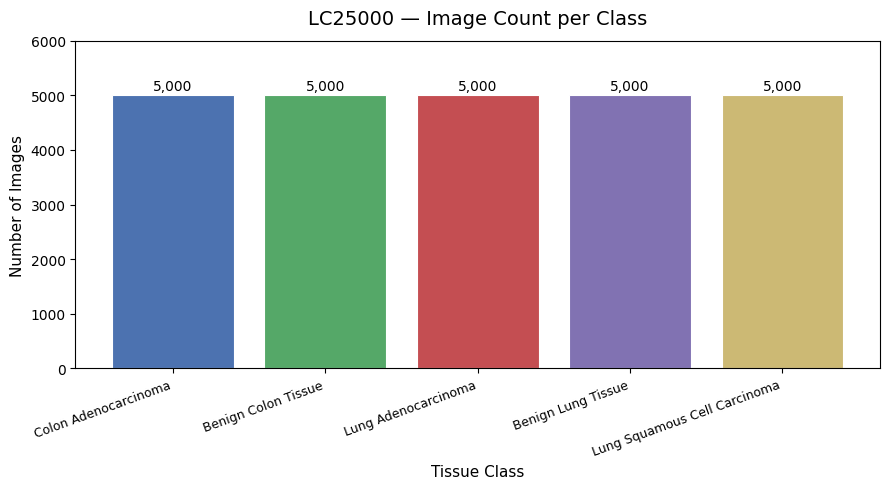

Figure saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/figures/01_class_distribution.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
bars = ax.bar(
    [CLASS_LABELS[k] for k in counts.keys()],
    counts.values(),
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

ax.set_title('LC25000 — Image Count per Class', fontsize=14, pad=12)
ax.set_xlabel('Tissue Class', fontsize=11)
ax.set_ylabel('Number of Images', fontsize=11)
ax.set_ylim(0, 6000)
ax.tick_params(axis='x', labelsize=9)

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 50,
        f'{int(height):,}',
        ha='center', va='bottom', fontsize=10
    )

plt.xticks(rotation=20, ha='right')
plt.tight_layout()

save_path = FIGURES_DIR / '01_class_distribution.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {save_path}")

### Observation — Class Distribution

The LC25000 dataset contains exactly 5,000 images per class across all five tissue categories. This perfect balance means that no class reweighting or oversampling is needed during training. Accuracy is a reliable metric for this dataset because there is no majority class that a model could exploit by predicting one class more often. The equal distribution also means that random chance performance sits at 20 percent, which gives a clear lower bound for evaluating all models.

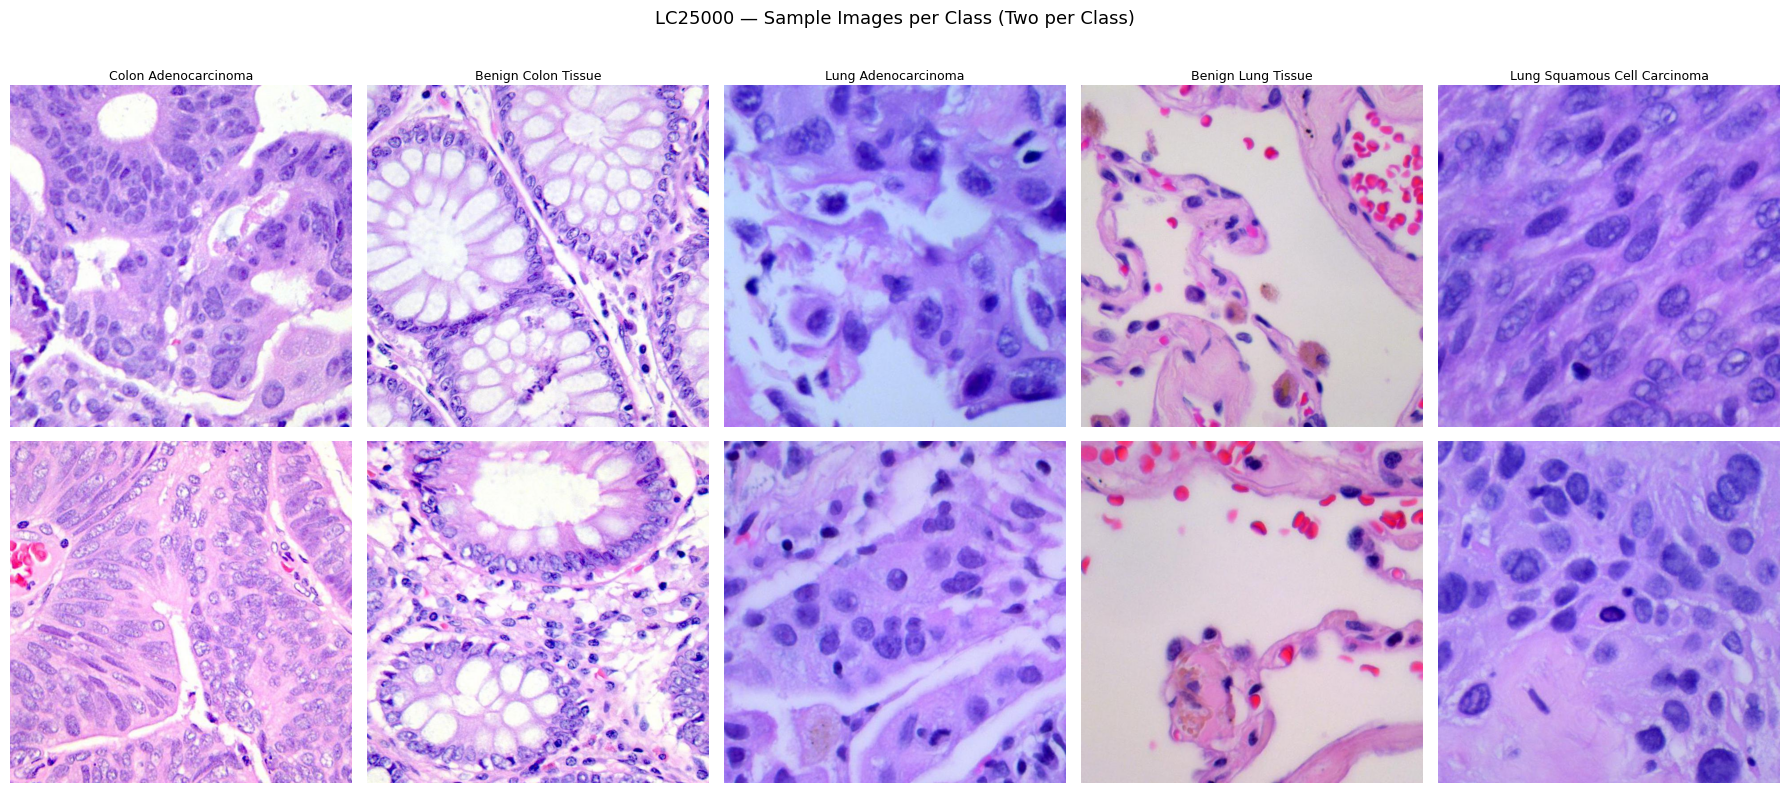

Figure saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/figures/01_sample_images.png


In [16]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('LC25000 — Sample Images per Class (Two per Class)', fontsize=13, y=1.01)

for col, (class_key, folder_path) in enumerate(CLASS_FOLDERS.items()):
    all_images = sorted(folder_path.glob('*.jpeg'))
    samples = random.sample(all_images, 2)

    for row in range(2):
        img = Image.open(samples[row]).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(CLASS_LABELS[class_key], fontsize=9, pad=4)

plt.tight_layout()
save_path = FIGURES_DIR / '01_sample_images.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {save_path}")

In [17]:
# Verify that all images share the same resolution
# Sample 50 images per class and record dimensions

dimension_records = []

for class_key, folder_path in CLASS_FOLDERS.items():
    all_images = sorted(folder_path.glob('*.jpeg'))
    sample = random.sample(all_images, 50)

    for img_path in sample:
        with Image.open(img_path) as img:
            w, h = img.size
            mode = img.mode
        dimension_records.append({
            'class'  : class_key,
            'width'  : w,
            'height' : h,
            'mode'   : mode,
        })

dim_df = pd.DataFrame(dimension_records)

print("Image dimension summary (sample of 50 per class):")
print(dim_df.groupby('class')[['width', 'height']].agg(['min', 'max', 'mean']))
print(f"\nColour modes found: {dim_df['mode'].unique()}")

Image dimension summary (sample of 50 per class):
          width             height            
            min  max   mean    min  max   mean
class                                         
colon_aca   768  768  768.0    768  768  768.0
colon_n     768  768  768.0    768  768  768.0
lung_aca    768  768  768.0    768  768  768.0
lung_n      768  768  768.0    768  768  768.0
lung_scc    768  768  768.0    768  768  768.0

Colour modes found: ['RGB']


In [18]:
# Attempt to open every image and record any that fail

corrupt_files = []

for class_key, folder_path in CLASS_FOLDERS.items():
    all_images = sorted(folder_path.glob('*.jpeg'))
    for img_path in all_images:
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            corrupt_files.append({'class': class_key, 'file': str(img_path), 'error': str(e)})

if corrupt_files:
    print(f"Found {len(corrupt_files)} corrupt file(s):")
    for entry in corrupt_files:
        print(f"  [{entry['class']}] {entry['file']} — {entry['error']}")
else:
    print("No corrupt files found. All images are readable.")

No corrupt files found. All images are readable.


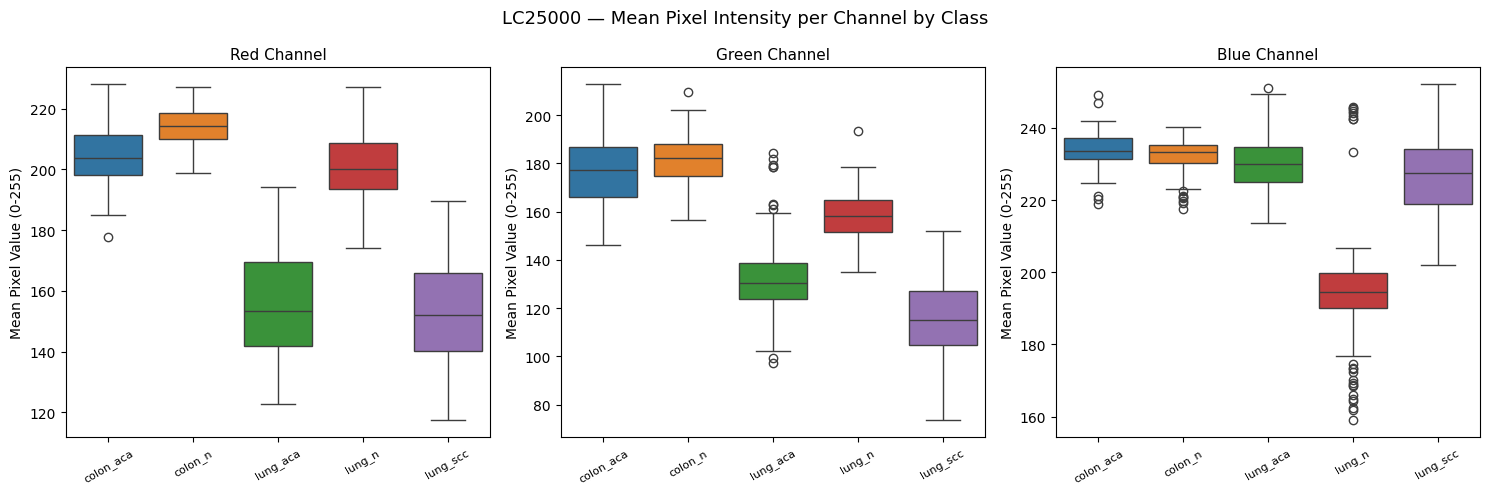

Figure saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/figures/01_pixel_intensity_distribution.png


In [19]:
# Sample 100 images per class and compute mean pixel intensity per channel (R, G, B)

intensity_records = []

for class_key, folder_path in CLASS_FOLDERS.items():
    all_images = sorted(folder_path.glob('*.jpeg'))
    sample = random.sample(all_images, 100)

    for img_path in sample:
        img_array = np.array(Image.open(img_path).convert('RGB'))
        intensity_records.append({
            'class': class_key,
            'mean_R': img_array[:, :, 0].mean(),
            'mean_G': img_array[:, :, 1].mean(),
            'mean_B': img_array[:, :, 2].mean(),
        })

intensity_df = pd.DataFrame(intensity_records)

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('LC25000 — Mean Pixel Intensity per Channel by Class', fontsize=13)

channels = ['mean_R', 'mean_G', 'mean_B']
channel_names = ['Red Channel', 'Green Channel', 'Blue Channel']
palette = sns.color_palette('tab10', n_colors=5)

for i, (channel, channel_name) in enumerate(zip(channels, channel_names)):
    sns.boxplot(
        data=intensity_df,
        x='class',
        y=channel,
        palette=palette,
        ax=axes[i]
    )
    axes[i].set_title(channel_name, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Mean Pixel Value (0-255)')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
save_path = FIGURES_DIR / '01_pixel_intensity_distribution.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {save_path}")

### Observation — Pixel Intensity Distribution

The boxplots reveal a clear difference in mean pixel intensity between
colon and lung tissue classes across all three colour channels. The two
colon classes, colon adenocarcinoma and benign colon tissue, consistently
show higher mean pixel values, sitting above 190 in the red channel and
above 170 in the green channel. The three lung classes show much lower
values, with lung adenocarcinoma and lung squamous cell carcinoma both
dropping below 160 in the red channel and below 140 in the green channel.
This pattern suggests that colon slides are brighter overall, likely
because they have more open space between glands and less densely packed
nuclei compared to lung tissue. The difference is consistent across all
three channels, which means it is a real stain or scanning difference
rather than a single channel artefact. This finding is important because
a model trained without stain normalisation could learn to separate colon
from lung tissue simply by brightness rather than by tissue morphology,
which would not work on slides from a different hospital or scanner.
Macenko stain normalisation in Notebook 02 directly addresses this problem.

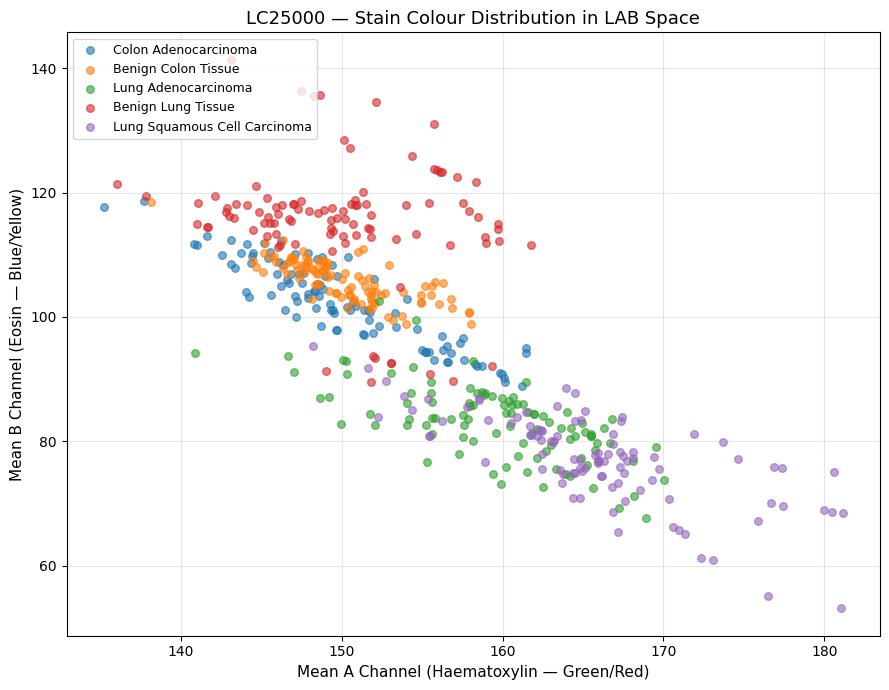

Figure saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/figures/01_lab_stain_distribution.png


In [20]:
# Convert images to LAB colour space and analyse the A and B channels
# A channel encodes green-red variation (haematoxylin)
# B channel encodes blue-yellow variation (eosin)

lab_records = []

for class_key, folder_path in CLASS_FOLDERS.items():
    all_images = sorted(folder_path.glob('*.jpeg'))
    sample = random.sample(all_images, 100)

    for img_path in sample:
        img_bgr = cv2.imread(str(img_path))
        img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        L, A, B = cv2.split(img_lab)

        lab_records.append({
            'class' : class_key,
            'mean_L': L.mean(),
            'mean_A': A.mean(),
            'mean_B': B.mean(),
            'std_A' : A.std(),
            'std_B' : B.std(),
        })

lab_df = pd.DataFrame(lab_records)

# Scatter plot: A vs B coloured by class
fig, ax = plt.subplots(figsize=(9, 7))

palette = sns.color_palette('tab10', n_colors=5)
class_keys = list(CLASS_FOLDERS.keys())

for i, class_key in enumerate(class_keys):
    subset = lab_df[lab_df['class'] == class_key]
    ax.scatter(
        subset['mean_A'],
        subset['mean_B'],
        label=CLASS_LABELS[class_key],
        alpha=0.6,
        s=30,
        color=palette[i]
    )

ax.set_xlabel('Mean A Channel (Haematoxylin — Green/Red)', fontsize=11)
ax.set_ylabel('Mean B Channel (Eosin — Blue/Yellow)', fontsize=11)
ax.set_title('LC25000 — Stain Colour Distribution in LAB Space', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = FIGURES_DIR / '01_lab_stain_distribution.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {save_path}")

### Observation — Stain Colour Distribution in LAB Space

The LAB scatter plot shows that the five tissue classes occupy different
regions in colour space, with a clear separation between colon and lung
tissue along both the A and B channels. The two colon classes cluster
together in the upper left of the plot, with lower A channel values around
140 to 155 and higher B channel values above 100. This reflects a stronger
eosin signal and less haematoxylin intensity in colon slides. The three
lung classes spread progressively toward the lower right, with lung
squamous cell carcinoma being the most separated, reaching A channel values
above 170 and B channel values as low as 55. This extreme separation for
lung squamous cell carcinoma is consistent with its known histological
appearance, where dense keratinisation and tightly packed cell clusters
absorb more haematoxylin stain, producing darker and more intensely
coloured images. Within the lung classes there is considerable overlap
between lung adenocarcinoma and benign lung tissue, which tells us that
these two classes will be harder for the model to separate and that
morphological features such as gland structure and nuclear arrangement
will matter more than colour for distinguishing them. The wide spread of
points within each class also confirms that stain intensity varies even
within the same tissue type, making normalisation important before training.

In [21]:
# Print a final EDA summary table

print(" " * 60)
print("  LC25000 EDA SUMMARY")
print(" " * 60)
print(f"  Total images       : {sum(counts.values()):,}")
print(f"  Number of classes  : {len(counts)}")
print(f"  Images per class   : {list(counts.values())[0]:,} (perfectly balanced)")
print(f"  Image dimensions   : 768 x 768 pixels")
print(f"  Colour mode        : RGB")
print(f"  Corrupt files      : {len(corrupt_files)}")
print(f"  Tissue sites       : Lung (3 classes) and Colon (2 classes)")
print(" " * 60)
print()
print("  Classes:")
for key, label in CLASS_LABELS.items():
    print(f"    {key:<12} — {label}")
print(" " * 60)
print()
print("  Key finding: Stain colour varies across classes and tissue sites.")
print("  Macenko stain normalisation will be applied in Notebook 02.")


                                                            
  LC25000 EDA SUMMARY
                                                            
  Total images       : 25,000
  Number of classes  : 5
  Images per class   : 5,000 (perfectly balanced)
  Image dimensions   : 768 x 768 pixels
  Colour mode        : RGB
  Corrupt files      : 0
  Tissue sites       : Lung (3 classes) and Colon (2 classes)
                                                            

  Classes:
    colon_aca    — Colon Adenocarcinoma
    colon_n      — Benign Colon Tissue
    lung_aca     — Lung Adenocarcinoma
    lung_n       — Benign Lung Tissue
    lung_scc     — Lung Squamous Cell Carcinoma
                                                            

  Key finding: Stain colour varies across classes and tissue sites.
  Macenko stain normalisation will be applied in Notebook 02.
